In [4]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------- ----------------------- 3.7/8.9 MB 21.7 MB/s eta 0:00:01
   -------------------------------------- - 8.7/8.9 MB 24.4 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 19.7 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   --- ------------------------------------ 3.4/41.3 MB 18.3 MB/s eta 0:00:03
   ------- -------------------------------- 7.3/41.3 MB 18.9 MB/s eta 0:00:02
   ---------- ----------------------------- 10.7/41.3 MB 18.6 MB/s eta 0:00:02
   -------------- ------------------------- 14.7/41.3 MB 18.4 MB/s eta 0:00:02
   ----------------- ---------------------- 18.1/41.3 MB 17.8 MB/s eta 0:00:02
   --------------------- ------------------ 22.0/41.3 MB

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [9]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Separate labels and pixels
y = train_df["label"].values
X = train_df.drop("label", axis=1).values

In [10]:
X = X / 255.0
test = test_df.values / 255.0

In [11]:
X = X.reshape(-1, 28, 28, 1)
test = test.reshape(-1, 28, 28, 1)

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [13]:
model = models.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

C:\Users\DELL\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_rotation (RandomRotation)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_translation                   │ ?                           │     0 (unbuilt) │
│ (RandomTranslation)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7774 - loss: 0.6823 - val_accuracy: 0.9640 - val_loss: 0.1102
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9244 - loss: 0.2512 - val_accuracy: 0.9800 - val_loss: 0.0677
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9465 - loss: 0.1837 - val_accuracy: 0.9833 - val_loss: 0.0577
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9557 - loss: 0.1507 - val_accuracy: 0.9819 - val_loss: 0.0549
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9626 - loss: 0.1292 - val_accuracy: 0.9869 - val_loss: 0.0471
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9652 - loss: 0.1181 - val_accuracy: 0.9857 - val_loss: 0.0590
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9686 - loss: 0.1062 - val_accuracy: 0.9876 - val_loss: 0.0414
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9698 - loss: 0.1020 - val_accura

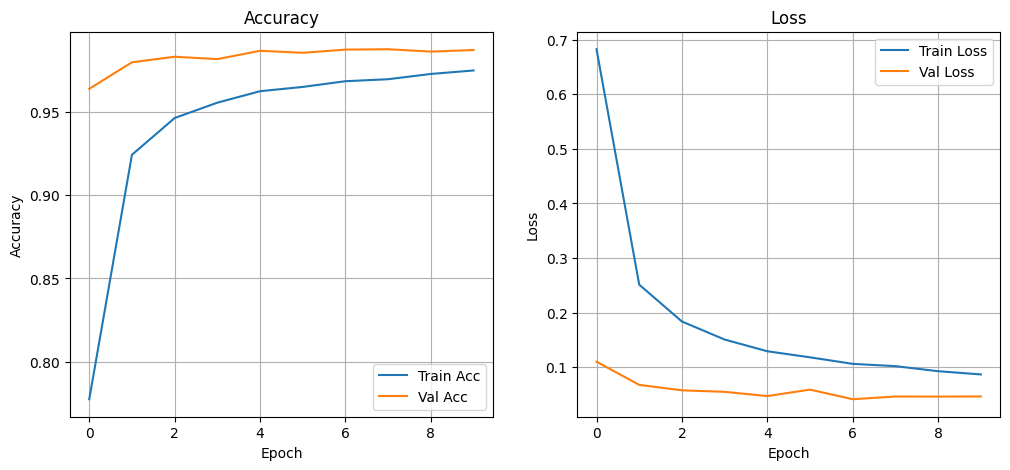

In [16]:
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [17]:
predictions = model.predict(test)
predicted_labels = np.argmax(predictions, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


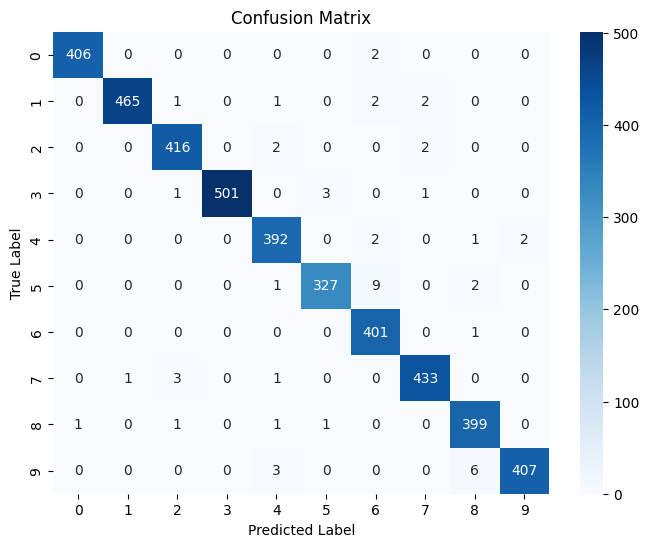

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict probabilities
predictions = model.predict(X_val)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [19]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(predicted_labels)+1),
    "Label": predicted_labels
})

submission.to_csv("submission.csv", index=False)

print("Submission file saved!")

Submission file saved!
